In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

# Cargar dataset
df = pd.read_csv("../data/processed/olympics_clean.csv")

# Ver filas
df.head()

,year,season,olympic_game,host_country,discipline_title,event_title,participant_type,country_name,country_code,country_3_letter_code,...,birth_year,athlete_age,total_games_participations,rank_position,medal_type,has_medal,gold,silver,bronze,total_medals
0,2022,Winter,Beijing 2022,China,Curling,Mixed Doubles,GameTeam,Italy,IT,ITA,...,NaN,NaN,NaN,1.0,GOLD,1,1,0,0,1
1,2022,Winter,Beijing 2022,China,Curling,Mixed Doubles,GameTeam,Norway,NO,NOR,...,NaN,NaN,NaN,2.0,SILVER,1,0,1,0,1
2,2022,Winter,Beijing 2022,China,Curling,Mixed Doubles,GameTeam,Sweden,SE,SWE,...,NaN,NaN,NaN,3.0,BRONZE,1,0,0,1,1
3,2022,Winter,Beijing 2022,China,Curling,Mixed Doubles,GameTeam,Great Britain,GB,GBR,...,NaN,NaN,NaN,4.0,NO_MEDAL,0,0,0,0,0
4,2022,Winter,Beijing 2022,China,Curling,Mixed Doubles,GameTeam,Canada,CA,CAN,...,NaN,NaN,NaN,5.0,NO_MEDAL,0,0,0,0,0


In [3]:
df.columns

Index(['year', 'season', 'olympic_game', 'host_country', 'discipline_title',
       'event_title', 'participant_type', 'country_name', 'country_code',
       'country_3_letter_code', 'athlete_full_name', 'athlete_url',
       'birth_year', 'athlete_age', 'total_games_participations',
       'rank_position', 'medal_type', 'has_medal', 'gold', 'silver', 'bronze',
       'total_medals'],
      dtype='str')

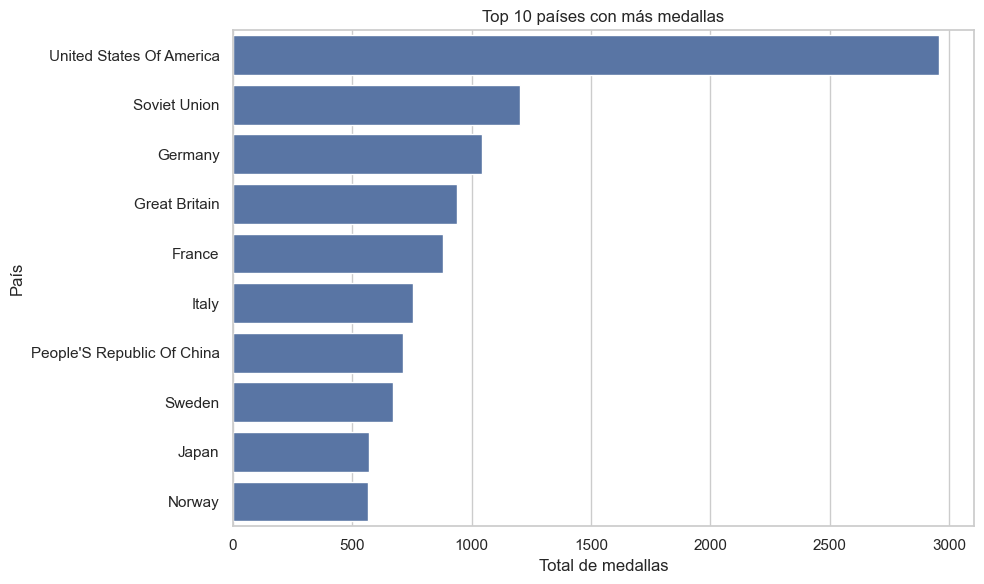

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filtrar medallas
df_medallas = df[df["has_medal"] == 1]

# Agrupar
top_paises = df_medallas.groupby("country_name").size().sort_values(ascending=False).head(10)
top_paises = top_paises.reset_index(name="total_medals")

# Crear figura
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(data=top_paises, x="total_medals", y="country_name", ax=ax)

ax.set_title("Top 10 países con más medallas")
ax.set_xlabel("Total de medallas")
ax.set_ylabel("País")

plt.tight_layout()
os.makedirs("../images", exist_ok=True)
fig.savefig("../images/top10_paises_medallas.png", dpi=300)

plt.show()

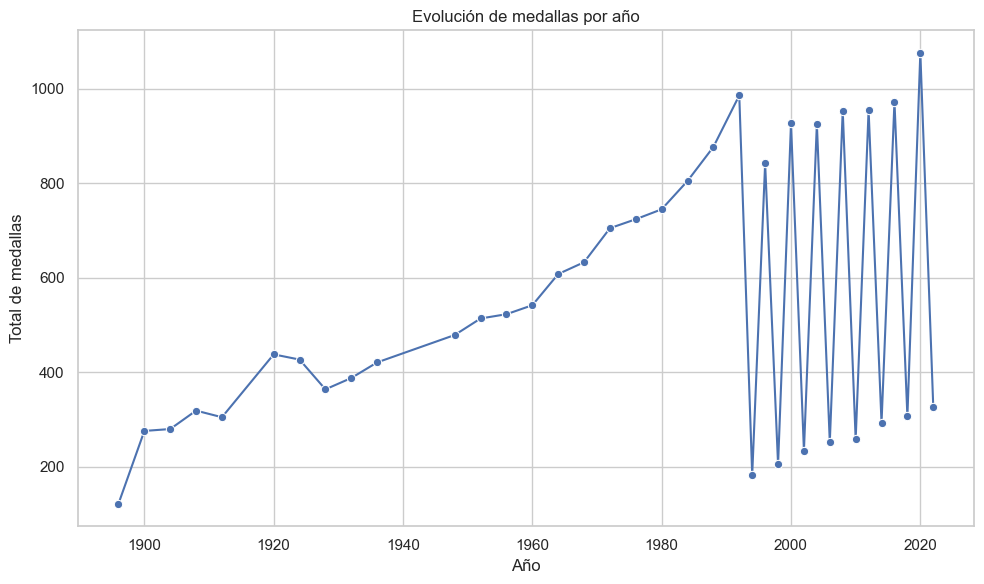

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filtrar solo medalla
df_medallas = df[df["has_medal"] == 1]

# Agrupar por año
medallas_por_anio = df_medallas.groupby("year").size().reset_index(name="total_medals")

# Crear figura
fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(data=medallas_por_anio, x="year", y="total_medals", marker="o", ax=ax)

ax.set_title("Evolución de medallas por año")
ax.set_xlabel("Año")
ax.set_ylabel("Total de medallas")

plt.tight_layout()

# Guardar imagen
os.makedirs("../images", exist_ok=True)
fig.savefig("../images/evolucion_medallas_anio.png", dpi=300)

plt.show()

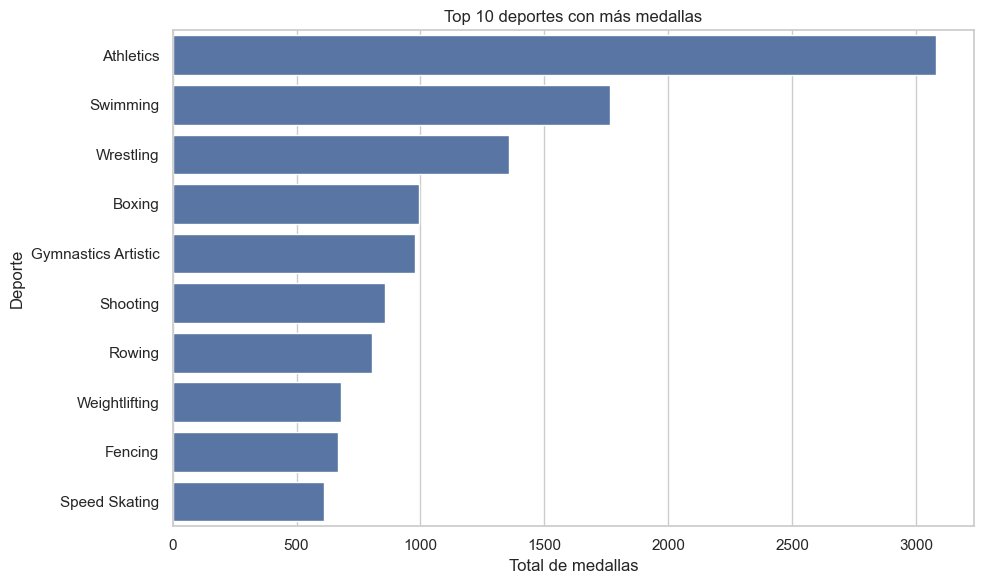

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Agrupar
top_deportes = (
    df.groupby("discipline_title")["total_medals"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Crear figura
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=top_deportes,
    x="total_medals",
    y="discipline_title",
    ax=ax
)

ax.set_title("Top 10 deportes con más medallas")
ax.set_xlabel("Total de medallas")
ax.set_ylabel("Deporte")

plt.tight_layout()

# Guardar
os.makedirs("../images", exist_ok=True)
fig.savefig("../images/top10_deportes_medallas.png", dpi=300)

plt.show()